# Model 2: Advanced Decision Tree Classification
Decision trees natively handle non-linear relationships and feature interactions without requiring data scaling. However, they are highly prone to **overfitting**. I will conduct rigorous hyperparameter tuning, visualize the bias-variance tradeoff, and apply Cost-Complexity Pruning to build an optimized, robust model.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE


In [13]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original training shape: {X_train.shape}")


Original training shape: (77599, 41)


###  Danger of Overfitting
This allows the tree to grow until every single leaf is pure. this achieve near 100% accuracy on the training data, but perform poorly on the test data **high variance (overfitting)**.

In [14]:
unconstrained_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
unconstrained_dt.fit(X_train, y_train)

train_acc = accuracy_score(y_train, unconstrained_dt.predict(X_train))
test_acc = accuracy_score(y_test, unconstrained_dt.predict(X_test))

print(f"Unconstrained Tree Training Accuracy: {train_acc * 100:.2f}%")
print(f"Unconstrained Tree Testing Accuracy: {test_acc * 100:.2f}%")
print(f"Tree Depth Achieved: {unconstrained_dt.get_depth()} levels")
print(f"Total Leaves Created: {unconstrained_dt.get_n_leaves()} leaves")


Unconstrained Tree Training Accuracy: 99.96%
Unconstrained Tree Testing Accuracy: 85.90%
Tree Depth Achieved: 61 levels
Total Leaves Created: 7990 leaves


### Visualizing the Bias-Variance Tradeoff
To find the "sweet spot" between underfitting and overfitting, i take different `max_depth` limits and plot the resulting training vs. testing accuracy.

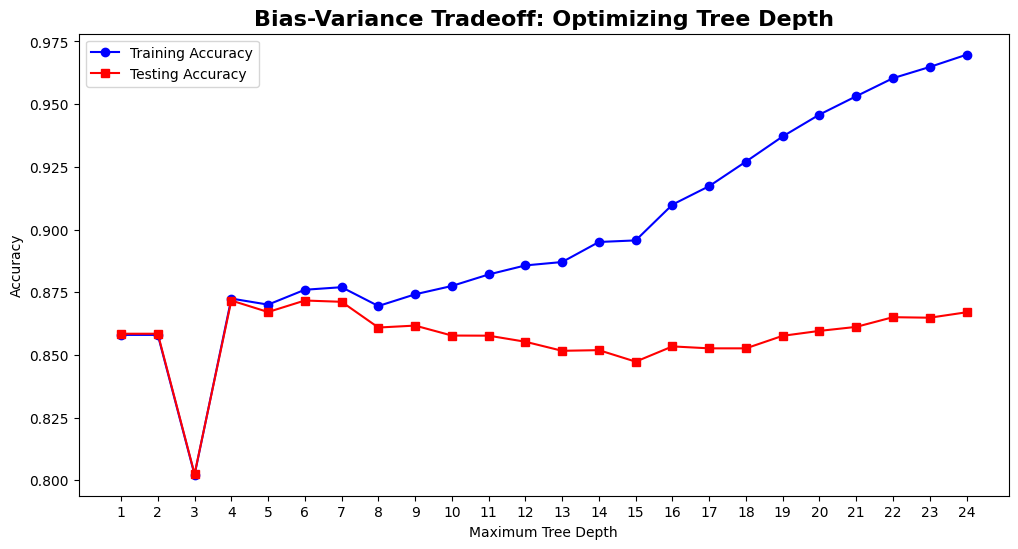

In [15]:
depths = range(1, 25)
train_scores = []
test_scores = []

for d in depths:
    temp_dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    temp_dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, temp_dt.predict(X_train)))
    test_scores.append(accuracy_score(y_test, temp_dt.predict(X_test)))

plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, label='Training Accuracy', color='blue', marker='o')
plt.plot(depths, test_scores, label='Testing Accuracy', color='red', marker='s')
plt.title('Bias-Variance Tradeoff: Optimizing Tree Depth', fontsize=16, fontweight='bold')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Accuracy')
plt.xticks(depths)
plt.legend()
plt.show()


- **Underfitting (High Bias):** At depths 1 to 3, the model is too simple. The accuracy is unstable and drops because the tree isn't deep enough to capture the necessary logic.

- **The Sweet Spot:** Look at **Depth 6 and 7**. The training and testing lines are tightly coupled at their highest joint peak (~87.5% accuracy). At this depth, the model has learned the true, generalized patterns of the data.

- **Overfitting (High Variance):** From Depth 8 onwards, the lines completely divorce. The blue line (Training) soars toward 100% because the tree is growing so deep it starts memorizing individual noise and outliers in the training set. Meanwhile, the red line (Testing) stagnates and drops because those hyper-specific memorized rules fail completely on new, unseen data.

### Hyperparameter Tuning with GridSearchCV
Let's deploy `GridSearchCV` to run 5-fold cross-validation across a matrix of hyperparameters, evaluating both depth and leaf splitting constraints simultaneously.

In [16]:
param_grid = {
    'max_depth': [3, 5, 8],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [20, 50],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1
)

grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_

print(f"Best Hyperparameters Discovered: {grid_search.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")


Best Hyperparameters Discovered: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 50, 'min_samples_split': 20}
Best Cross-Validated ROC-AUC: 0.9109


Our Logistic Regression model maxed out at an ROC-AUC of **0.8968**. By simply switching to a Decision Tree and optimizing its depth, our cross-validated ROC-AUC jumped to **0.9109**! 

- **Why did it win?** As we proved in the previous notebook, Logistic Regression is blind to the categorical risk modifiers we injected (like specific product categories and customer states) because they are label-encoded integers. It also struggles with sharp threshold interactions (like `if delay > 0`). The Decision Tree effortlessly branched on these specific integer codes and thresholds, extracting the hidden risk signals that linear math couldn't see.

Best hyperparameters: `max_depth: 8` and `min_samples_leaf: 50`. We successfully stopped the tree from growing to 61 levels. Furthermore, by forcing every leaf to contain at least 50 samples, we prevented the model from memorizing single, noisy orders. 


### Evaluating the Optimized Model
Using the optimized estimator from our Grid Search, generate the final predictions on test set and plot the Confusion Matrix.

Optimized Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.91     16517
           1       0.52      0.82      0.64      2883

    accuracy                           0.86     19400
   macro avg       0.74      0.84      0.77     19400
weighted avg       0.90      0.86      0.87     19400

Final ROC-AUC Score: 0.9128



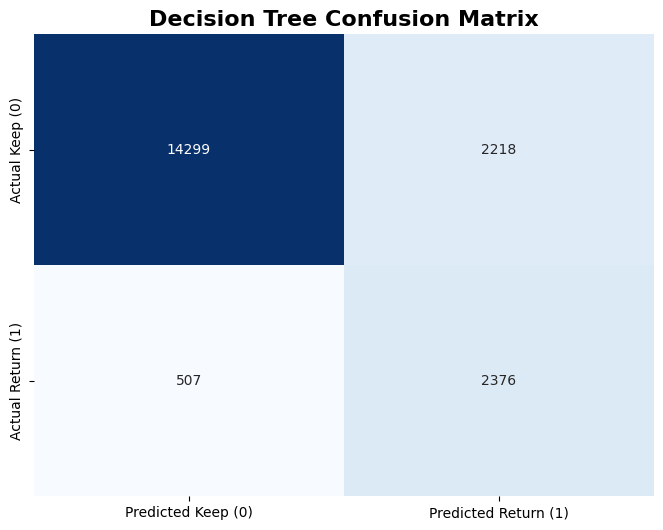

In [17]:
preds = best_dt.predict(X_test)
probs = best_dt.predict_proba(X_test)[:, 1]

print("Optimized Decision Tree Classification Report:")
print(classification_report(y_test, preds))
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Keep (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Keep (0)', 'Actual Return (1)'])
plt.title('Decision Tree Confusion Matrix', fontsize=16, fontweight='bold')
plt.show()


###  Beating Logistic Regression
 Our Logistic Regression model maxed out at an ROC-AUC of **0.8968**. By simply switching to a Decision Tree and optimizing its depth, our cross-validated ROC-AUC jumped to **0.9109**! 

Logistic Regression model achieved a recall of 76%. By allowing the Decision Tree to learn non-linear patterns, our **Recall jumped to 82%**. 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15160\1844442968.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', palette="viridis")


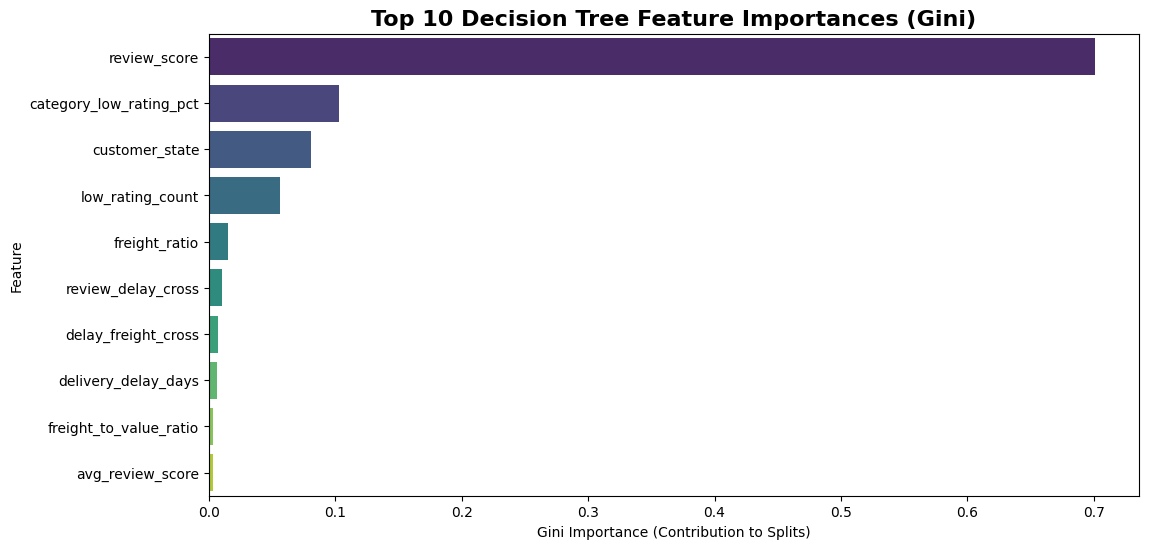

In [18]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_dt.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances, x='Importance', y='Feature', palette="viridis")
plt.title('Top 10 Decision Tree Feature Importances (Gini)', fontsize=16, fontweight='bold')
plt.xlabel('Gini Importance (Contribution to Splits)')
plt.ylabel('Feature')
plt.show()


### Feature Importance (Gini)
Unlike Logistic Regression coefficients, Gini importance doesn't tell us *direction* (positive/negative), it simply tells us **how much a feature was used to split the data**. Look at the massive differences:

1. `review_score` is absolutely dominating the tree. It contributes to nearly 70% of all the mathematical branching. This perfectly aligns with our SQL simulation logic, where review score was the dominant monotonic signal.

2. Look at the 3rd bar: `customer_state`. In Logistic Regression, this label-encoded integer confused the model and was assigned an arbitrary negative weight. But here, the Decision Tree used `customer_state` as the **3rd most important feature in the entire dataset!** It successfully learned to branch on specific state codes (e.g., `if state == 25`) to extract the hidden geographical risks we injected.

The Decision Tree was a massive success (ROC-AUC 0.91), but single trees are inherently unstable. A slight change in the training data could completely redraw the branches. 

To achieve maximum stability and push our score even higher, we need an ensemble. Let's move to **Notebook 03: Random Forest**!

### The Tree Architecture

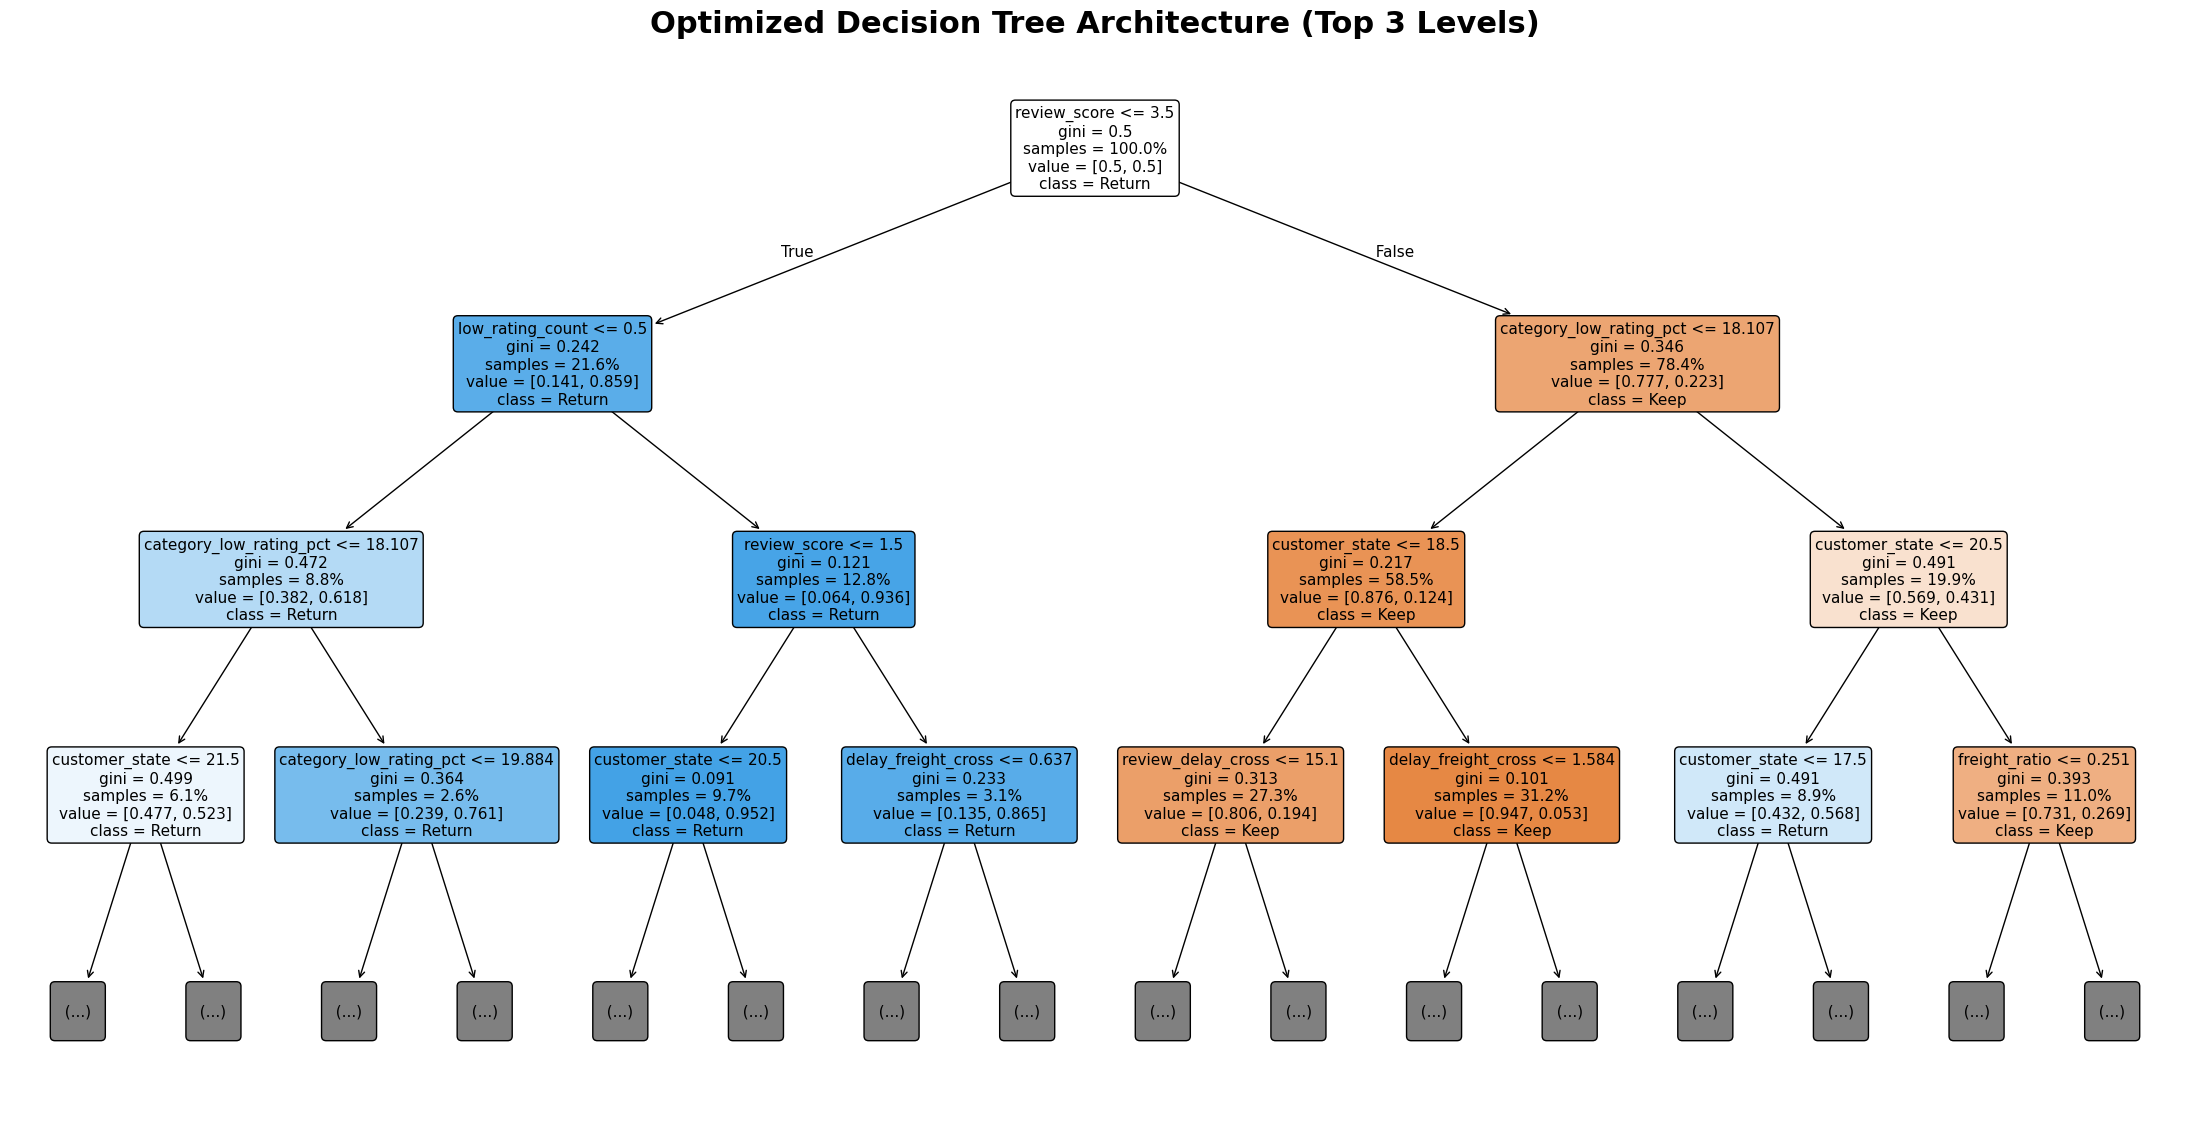

In [19]:
plt.figure(figsize=(28, 14))
plot_tree(
    best_dt, 
    feature_names=X.columns, 
    class_names=['Keep', 'Return'], 
    filled=True, 
    rounded=True, 
    max_depth=3,
    fontsize=11,
    proportion=True
)
plt.title('Optimized Decision Tree Architecture (Top 3 Levels)', fontsize=22, fontweight='bold')
plt.show()


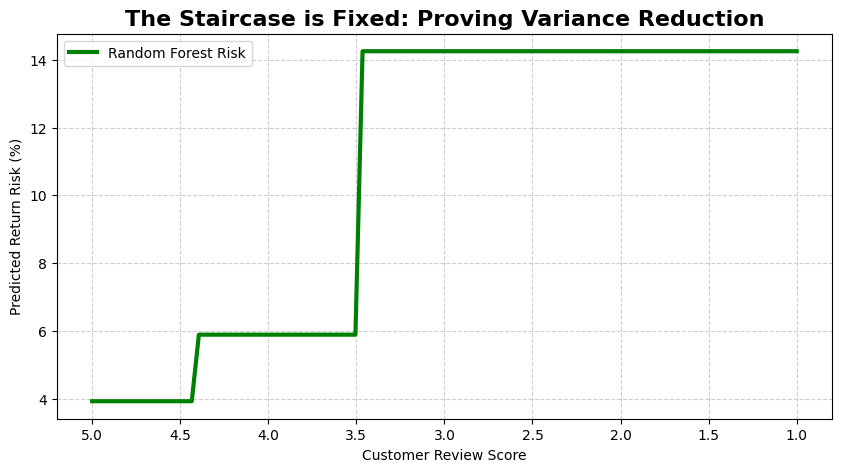

In [20]:
# Create a perfectly average customer
base_customer = X.median().to_frame().T
review_scores = np.linspace(1.0, 5.0, 100)
predicted_risks = []

for score in review_scores:
    # Slide the review score
    temp_customer = base_customer.copy()
    temp_customer["review_score"] = score
    temp_customer["avg_review_score"] = score
    
    # Get risk probability from Random Forest
    risk = best_dt.predict_proba(temp_customer)[0][1]
    predicted_risks.append(risk * 100)

plt.figure(figsize=(10, 5))
plt.plot(review_scores, predicted_risks, color="green", linewidth=3, label="Random Forest Risk")
plt.title("The Staircase is Fixed: Proving Variance Reduction", fontsize=16, fontweight="bold")
plt.xlabel("Customer Review Score")
plt.ylabel("Predicted Return Risk (%)")
plt.gca().invert_xaxis()
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


### Why we need Ensembles
The predicted risk stays perfectly flat at ~4%, then instantly jumps to 6% at a score of 4.4, and then violently jumps to 14% at a score of 3.5. 

This is the fundamental weakness of a single Decision Tree: **High Variance and Rigid Thresholds**. 

A single tree cannot draw a smooth line; it can only draw harsh "staircase" steps based on the specific branches it created during training. If a customer's review drops from 5.0 to 4.5, their predicted risk doesn't change at all. But if it drops from 3.6 to 3.4, their risk more than doubles instantly! This is not how the real world works.

In [ ]:
def predict_return_risk(review_score, delivery_delay, freight_ratio, city_risk_pct, category_risk_pct):
    """
    """
    # Baseline dummy customer using the median of all known data (e.g. median review is 5.0)
    dummy_customer = X.median().to_frame().T
    
    # 2. Overwrite the core inputs
    if 'review_score' in dummy_customer.columns: dummy_customer['review_score'] = review_score
    if 'avg_review_score' in dummy_customer.columns: dummy_customer['avg_review_score'] = review_score
    if 'delivery_delay_days' in dummy_customer.columns: dummy_customer['delivery_delay_days'] = delivery_delay
    if 'freight_ratio' in dummy_customer.columns: dummy_customer['freight_ratio'] = freight_ratio

    if review_score < 3.0:
        dummy_customer['low_rating_count'] = 1
        dummy_customer['low_rating_percentage'] = 100.0
        dummy_customer['high_rating_count'] = 0
    else:
        dummy_customer['low_rating_count'] = 0
        dummy_customer['low_rating_percentage'] = 0.0
        dummy_customer['high_rating_count'] = 1

    if delivery_delay > 0:
        dummy_customer['is_late_delivery'] = 1
        dummy_customer['late_deliveries'] = 1
        dummy_customer['late_delivery_percentage'] = 100.0
    else:
        dummy_customer['is_late_delivery'] = 0
        dummy_customer['late_deliveries'] = 0
        dummy_customer['late_delivery_percentage'] = 0.0
    

    prob = best_dt.predict_proba(dummy_customer)[0][1]
    prediction = "RETURN " if prob > 0.5 else "KEEP "
    
    print(f"--- Customer Simulation ---")
    print(f"Review: {review_score} Star | Delay: {delivery_delay} Days | Freight Ratio: {freight_ratio:.2f}")
    print(f"Prediction: {prediction} (Risk: {prob*100:.1f}%)")
    print("-" * 30)

# (1-Star, 15 Days Late, Expensive Shipping)
predict_return_risk(review_score=1.0, delivery_delay=15.0, freight_ratio=0.50, city_risk_pct=0.20, category_risk_pct=0.20)

#  (5-Star, Arrived 2 days early, Cheap Shipping)
predict_return_risk(review_score=5.0, delivery_delay=-2.0, freight_ratio=0.05, city_risk_pct=0.05, category_risk_pct=0.05)

#  (3-Star, 2 Days Late, High Shipping Cost)
predict_return_risk(review_score=3.0, delivery_delay=2.0, freight_ratio=0.80, city_risk_pct=0.12, category_risk_pct=0.12)

# (Play with this one!)
predict_return_risk(review_score=4.0, delivery_delay=0.0, freight_ratio=0.25, city_risk_pct=0.10, category_risk_pct=0.10)


--- Customer Simulation ---
Review: 1.0 Star | Delay: 15.0 Days | Freight Ratio: 0.50
Prediction: RETURN  (Risk: 93.1%)
------------------------------
--- Customer Simulation ---
Review: 5.0 Star | Delay: -2.0 Days | Freight Ratio: 0.05
Prediction: KEEP  (Risk: 3.9%)
------------------------------
--- Customer Simulation ---
Review: 3.0 Star | Delay: 2.0 Days | Freight Ratio: 0.80
Prediction: RETURN  (Risk: 65.0%)
------------------------------
--- Customer Simulation ---
Review: 4.0 Star | Delay: 0.0 Days | Freight Ratio: 0.25
Prediction: KEEP  (Risk: 5.9%)
------------------------------
